# 8.16 Time-Dependent Density-Functional Theory

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VIII — Electronic Structure and Many-Body Matter",
    number="8.16",
    title="Time-Dependent Density-Functional Theory",
    blurb="The exact two-electron laboratory of §8.2 is set in motion. A "
    "momentum kick plus Crank–Nicolson propagation turns one dipole "
    "signal into a complete optical spectrum whose peaks land on the "
    "exact excitation energies to 2×10⁻⁴ — with the triplet and "
    "parity-forbidden states correctly, measurably silent. The same "
    "kick is then run through the two workhorse approximations: "
    "time-dependent Hartree–Fock blue-shifts the first excitation by "
    "3% (missing correlation, quantified), while orbital-free Hartree — "
    "self-interaction left in — wrecks the spectrum beyond recognition. "
    "Approximate quantum dynamics, judged against exact quantum "
    "dynamics, on the one system where both are affordable.",
    difficulty="advanced",
    estimate="150–180 min",
)

<ECP header: 3047 chars of HTML>

## Notebook overview

[§8.15](optics-excitons.ipynb) computed spectra from *eigenstates* —
linear response assembled state by state. Real electron dynamics is
richer: attosecond pulses, strong fields, charge transfer — regimes
where one wants to *propagate* electrons in time. The exact
time-dependent Schrödinger equation for $N$ electrons is as intractable
as the static one, and the resolution is the same maneuver that built
[§8.6](hohenberg-kohn.ipynb): Runge and Gross {cite}`rungegross1984`
proved that the time-dependent *density* $n(x, t)$ determines the
time-dependent potential, licensing a time-dependent Kohn–Sham scheme.
But where static DFT has [§8.8](exact-conditions-band-gap.ipynb)'s
well-mapped failure modes, time-dependent functionals are younger and
rougher terrain {cite}`ullrich2012` — which makes an *exact testing
ground* worth everything. This volume owns one.

The build: [§8.2](exact-laboratory.ipynb)'s two-electron soft-Coulomb
atom returns, its full $(x_1, x_2)$ wavefunction now *propagated* by
Crank–Nicolson — unconditionally unitary by construction, written here
for the sparse Hamiltonian of
[§6.10](../06-quantum-mechanics/schrodinger-on-a-computer.ipynb)'s grid
with an LU factorization reused across four thousand steps, so the norm
is conserved to $10^{-8}$ over the whole run. The
spectroscopy protocol is the standard one of real-time TDDFT codes: a
weak momentum kick $e^{\mathrm i\kappa X}$ at $t = 0$, the dipole
$\langle X\rangle(t)$ recorded, its Fourier transform read as the
absorption spectrum. Certification first: the exact propagation's peaks
must land on the exact eigenstate differences — they do, at
$2\times10^{-4}$ — and the states that symmetry forbids must be
*absent*: the triplet at $\Delta E = 0.422$ (spin symmetry preserved by
propagation) and the even-parity singlet at $0.615$ (dipole parity),
both measurably silent. Linearity is verified by halving the kick
(response ratio $2.00$). Then the judgment: the same kick through
time-dependent Hartree–Fock (for two electrons, exact exchange —
adiabatic, correlation-free) blue-shifts the first peak to $0.550$
against the exact $0.534$, a $3\%$ error the notebook prices; and
through time-dependent *Hartree* — self-interaction uncorrected — which
scatters spurious structure across the spectrum, the dynamical face of
the self-interaction disease [§8.8](exact-conditions-band-gap.ipynb)
diagnosed statically. One system, three dynamics, every claim gated.

> **Conventions (this notebook).** Atomic units. The laboratory is
> [§8.2](exact-laboratory.ipynb)'s: $v(x) = -2/\sqrt{x^2+1}$,
> interaction $w(u) = 1/\sqrt{u^2+1}$, grid $x \in [-10, 10]$ with
> $N = 121$ points (spacing $1/6$), two electrons in a spin singlet
> (symmetric spatial wavefunction). Sparse Hamiltonians as in
> [§8.2](exact-laboratory.ipynb)
> (Kronecker sums, `scipy.sparse`); statics by `eigsh`; dynamics by
> Crank–Nicolson with `scipy.sparse.linalg.splu` factorized once
> ($\Delta t = 0.05$, $4000$ steps). Spectra: kick $\kappa = 10^{-3}$,
> Hann window, zero-padded `numpy.fft.rfft` of
> $\langle X\rangle(t) - \langle X\rangle(0)$.
>
> **How to read the checks.** Each exercise closes with a `validate`
> call against an independent fact: a conservation law, an eigenstate
> difference, a selection rule, a linearity ratio. A ✓ is strong
> evidence; a ✗ is a prompt to locate the discrepancy, not an
> automatic verdict.
>
> **Scope.** Real-time propagation and kick spectroscopy for one
> closed-shell pair, with time-dependent Hartree and Hartree–Fock as
> the approximate dynamics (for two singlet electrons TDHF *is*
> time-dependent exact exchange, so the comparison isolates adiabatic
> correlation). Production TDDFT — ALDA and beyond, memory effects,
> double excitations, Casida's matrix formulation — is Ullrich's
> monograph {cite}`ullrich2012`.

## Theory in brief

### Runge–Gross, and why propagation is spectroscopy

The Runge–Gross theorem {cite}`rungegross1984` is the time-dependent
twin of [§8.6](hohenberg-kohn.ipynb): two potentials differing by more
than $c(t)$ cannot produce the same evolving density from the same
initial state — so $n(x, t)$ is, in principle, a complete record of the
dynamics. The practical protocol reads the record spectroscopically.
Kick the ground state with a uniform momentum boost,

```{math}
:label: eq-td-kick
\Psi(t{=}0^+) = e^{\mathrm i\kappa X}\,\Psi_0,
\qquad X = x_1 + x_2 ,
```

which populates every dipole-connected eigenstate with amplitude
$\propto \kappa\,\langle n|X|0\rangle$. The dipole then rings,

```{math}
:label: eq-td-dipole
\langle X\rangle(t) - \langle X\rangle(0) \;=\;
2\kappa \sum_n \big|\langle n|X|0\rangle\big|^2
\sin\!\big(\omega_{n0}t\big) + O(\kappa^2) ,
```

so the Fourier transform of one real-time signal *is* the absorption
spectrum: peak positions at exact excitation energies, weights at
dipole strengths — precisely how real-time TDDFT codes compute optical
spectra of molecules. The kick must be weak ({eq}`eq-td-dipole` is
first order in $\kappa$), and weakness is checkable: halve $\kappa$,
the response must halve.

### Crank–Nicolson, unitary by construction

Propagation steps
[§6.10](../06-quantum-mechanics/schrodinger-on-a-computer.ipynb)'s grid
Hamiltonian in time by the Crank–Nicolson scheme:

```{math}
:label: eq-td-cn
\Big(\mathbb 1 + \tfrac{\mathrm i\Delta t}{2} H\Big)\,\Psi_{t+\Delta t}
\;=\; \Big(\mathbb 1 - \tfrac{\mathrm i\Delta t}{2} H\Big)\,\Psi_t ,
```

exactly unitary for Hermitian $H$ (the two factors are conjugate), so
the norm is conserved to solver precision no matter how long the run.
For the exact problem $H$ is time-independent and the sparse LU
factorization of the left-hand matrix is computed *once*; for the
self-consistent dynamics (TDH/TDHF) the potential depends on the
evolving density and the linear system is rebuilt each step.

### The two approximate dynamics

Both electrons share one orbital $\varphi(x, t)$; the approximations
differ in the mean field it feels:

```{math}
:label: eq-td-meanfield
\mathrm i\,\partial_t\varphi = \Big[-\tfrac12\partial_x^2 + v(x)
+ c\,v_{\mathrm H}[n](x, t)\Big]\varphi,
\qquad n = 2|\varphi|^2 ,
```

with $c = \tfrac12$ for **TDHF** (the exchange integral for a doubly
occupied orbital cancels exactly half the Hartree term — each electron
feels only the *other* one; self-interaction-free, correlation-free)
and $c = 1$ for **TD-Hartree** (each electron repels the full density,
*itself included* — the self-interaction error of
[§8.8](exact-conditions-band-gap.ipynb), now propagating). Adiabatic
TDDFT with an exact-exchange functional coincides with TDHF for this
system, so the TDHF-versus-exact gap below *is* the adiabatic
exchange-only TDDFT error.

## Setup

Data and instruments: the series palette, the laboratory's box and working
grid, the given external potential and interaction of the Conventions, and
the one- and two-electron sparse Hamiltonians whose construction was the
lesson of [§6.10](../06-quantum-mechanics/schrodinger-on-a-computer.ipynb)
and [§8.2](exact-laboratory.ipynb). The notebook's own machinery — the
Crank–Nicolson propagator, the spectrum-maker that turns its dipole record
into a spectrum, and the self-consistent mean-field dynamics — you build in
Exercises 2, 3 and 4.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.sparse import diags, identity, kron
from scipy.sparse.linalg import eigsh, splu

from ecp import validate

# data: the series palette
INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"

# data: the laboratory of §8.2 — the same box, on the coarser N = 121 working
# grid the Conventions fix for a run that must be propagated 4000 times
L_BOX, N_GRID = 10.0, 121
x_grid = np.linspace(-L_BOX, L_BOX, N_GRID)
DX = x_grid[1] - x_grid[0]

# built from scratch in §6.10 (Exercise 1's `hamiltonian(x, V)`: the (1, -2, 1)
# stencil plus diag V, certified Hermitian there); restated here as an
# instrument, sparse and in atomic units. V_EXT itself is data — the given
# external potential v(x) = -2/√(x²+1) of the Conventions.
lap = diags([1.0, -2.0, 1.0], [-1, 0, 1], shape=(N_GRID, N_GRID)) / DX**2
KIN_1D = -0.5 * lap
V_EXT = -2.0 / np.sqrt(x_grid**2 + 1.0)
H_1D = KIN_1D + diags(V_EXT)

# built from scratch in §8.2 (Exercise 2's `two_body(x)`: the Kronecker sum of
# two one-body Hamiltonians plus the flattened interaction on the diagonal);
# restated here as an instrument — this notebook sets that Hamiltonian in
# motion, it does not re-derive it. W_EE is the given interaction w(u) =
# 1/√(u²+1) of the Conventions and X_TOTAL the kick operator X = x₁ + x₂,
# both on the flattened (x₁, x₂) grid.
X1_MESH, X2_MESH = np.meshgrid(x_grid, x_grid, indexing="ij")
W_EE = 1.0 / np.sqrt((X1_MESH - X2_MESH) ** 2 + 1.0)
EYE = identity(N_GRID)
H_2E = (kron(H_1D, EYE) + kron(EYE, H_1D) + diags(W_EE.ravel())).tocsc()
X_TOTAL = (X1_MESH + X2_MESH).ravel()

# data: the same given interaction, laid out as the full (N, N) kernel matrix
# the mean-field dynamics of Exercise 4 integrates the density against
W_KERNEL = 1.0 / np.sqrt((x_grid[:, None] - x_grid[None, :]) ** 2 + 1.0)

## Exercise 1 — The laboratory, reopened and classified

Before dynamics, statics: the exact spectrum, with every state's
symmetry papers in order.

**Part a)** Diagonalize the two-electron Hamiltonian (`eigsh`, eight
lowest states) and classify each by *exchange* symmetry
($\psi(x_1, x_2) = \pm\psi(x_2, x_1)$: singlet/triplet spatial parts,
[§6.20](../06-quantum-mechanics/identical-particles.ipynb)) and by
*parity* ($\psi(-x_1, -x_2) = \pm\psi$). Ground state $E_0 = -2.2391$,
symmetric and even, as [§8.2](exact-laboratory.ipynb) built it.

**Part b)** Mark the dipole-active states. The kick operator $X$ is
symmetric under exchange and odd under parity, so from the ground
state only *singlet, odd-parity* states can light up: states $2$
($\Delta E = 0.5339$) and $6$ ($\Delta E = 0.7147$) among the eight.
The triplet at $0.4220$ and the even singlet at $0.6145$ are on the
forbidden list — Exercise 3 checks that the dynamics respects it.

In [3]:
# (solution hidden on the public site)


E0 = -2.239071   singlet, even   dE = 0.0000
E1 = -1.817061   triplet, odd    dE = 0.4220
E2 = -1.705177   singlet, odd    dE = 0.5339  <- dipole-active
E3 = -1.641304   triplet, even   dE = 0.5978
E4 = -1.624584   singlet, even   dE = 0.6145
E5 = -1.558019   triplet, odd    dE = 0.6811
E6 = -1.524355   singlet, odd    dE = 0.7147  <- dipole-active
E7 = -1.461868   triplet, even   dE = 0.7772

dipole-active excitations: ['0.5339', '0.7147']


### Validation 1 — papers in order

The ground energy, the two allowed excitations, and a spectrum that is
neither all-singlet nor all-triplet (the classifier actually
classifies).

In [4]:
validate.close(e_ground, -2.2391, "ground energy of the exact laboratory", atol=1e-3)
validate.close(active_energies[0], 0.5339, "first dipole-active excitation", atol=1e-3)
validate.close(active_energies[1], 0.7147, "second dipole-active excitation", atol=1e-3)
validate.check(
    bool(2 <= n_singlets <= 6 and len(active_energies) == 2),
    "classifier separates singlets, triplets, parities",
    f"{n_singlets} singlets, 2 dipole-active",
)

✓  ground energy of the exact laboratory   [got -2.23907 vs expected -2.2391 (rtol=1e-06, atol=0.001)]
✓  first dipole-active excitation   [got 0.533894 vs expected 0.5339 (rtol=1e-06, atol=0.001)]
✓  second dipole-active excitation   [got 0.714716 vs expected 0.7147 (rtol=1e-06, atol=0.001)]
✓  classifier separates singlets, triplets, parities   [4 singlets, 2 dipole-active]


True

## Exercise 2 — Exact dynamics: kicked, unitary, linear

The full $(x_1, x_2)$ wavefunction goes into real time. Three facts shape
the propagator. The kick of {eq}`eq-td-kick` is a pure phase
$e^{\mathrm i\kappa X}$ on Exercise 1's ground state — a momentum boost
that leaves the density at $t = 0^+$ untouched, only the current changes.
The Crank–Nicolson step of {eq}`eq-td-cn` is one sparse linear solve,
and because the exact $H$ carries no time dependence the left-hand matrix
$\mathbb 1 + \tfrac{\mathrm i\Delta t}{2}H$ is the *same* matrix at every
step: one `scipy.sparse.linalg.splu` factorization, then four thousand
cheap back-substitutions, and a $200$-a.u. run of a $14641$-dimensional
problem costs seconds. And the observable, the dipole
$\langle X\rangle = \langle\Psi|X|\Psi\rangle/\langle\Psi|\Psi\rangle$,
is worth dividing by the running norm so that the unitarity gate stays an
independent check rather than a hidden ingredient of the signal. Two facts
then stand ready to be tested against: exact unitarity is Crank–Nicolson's
defining structural virtue, and {eq}`eq-td-dipole` holds only to first
order in $\kappa$, so a response that is genuinely linear must halve when
the kick does.

**Part a)** Write `propagate_exact(kick, n_steps, dt=0.05)`: phase the
ground state by the kick, factorize the Crank–Nicolson left-hand matrix
once, step `n_steps` times recording $\langle X\rangle(t)$ at each step,
and return the dipole record together with the final norm. **Write this
one yourself** — the implementation is the lesson.

**Part b)** Run it at $\kappa = 10^{-3}$ for $4000$ steps of
$\Delta t = 0.05$ — the record the rest of the notebook reads.

**Part c)** Certify unitarity: the norm after $4000$ steps must equal
$1$ to $10^{-8}$ — Crank–Nicolson's defining virtue, not a numerical
accident.

**Part d)** Certify linearity: rerun with $\kappa/2$ and confirm the
dipole response amplitude halves (ratio $2.00$ within $1\%$) — the
spectroscopy below is measuring the *linear* response, as
{eq}`eq-td-dipole` requires.

In [5]:
# (solution hidden on the public site)


norm after 4000 steps: 1.0000000000


linearity: response ratio for kick ratio 2 = 2.0000


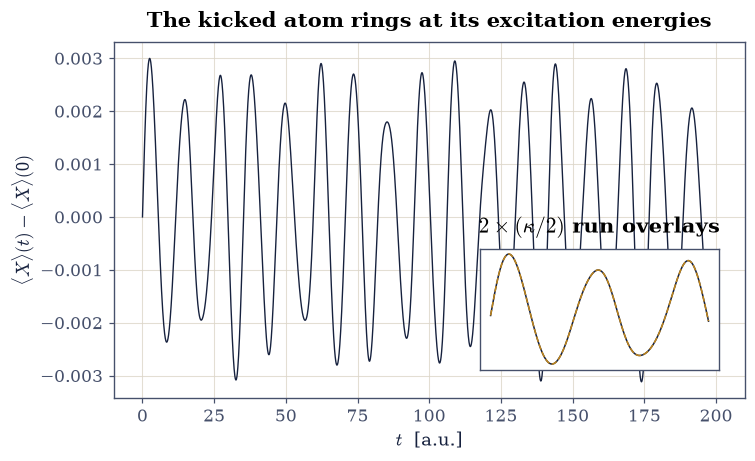

In [6]:
# (solution hidden on the public site)


### Validation 2 — unitary and linear, certified

Norm conservation at $10^{-8}$ over $4000$ steps; response linear in
the kick at $1\%$.

In [7]:
validate.check(
    bool(abs(norm_final - 1.0) < 1e-8),
    "Crank-Nicolson conserves the norm over the whole run",
    f"drift {abs(norm_final-1.0):.1e}",
)
validate.close(lin_ratio, 2.0, "response linear in the kick", rtol=1e-2)

✓  Crank-Nicolson conserves the norm over the whole run   [drift 2.6e-13]
✓  response linear in the kick   [got 2 vs expected 2 (rtol=0.01, atol=1e-09)]


True

## Exercise 3 — Spectroscopy: peaks where allowed, silence where not

Equation {eq}`eq-td-dipole` says the dipole record of Exercise 2 is a sum
of sinusoids at the excitation energies, weighted by dipole strengths — so
its Fourier transform *is* the absorption spectrum, and the whole of this
notebook's spectroscopy is one transform away. Three details separate a
usable spectrum from a smeared one. The signal must be centered on
$\langle X\rangle(0)$, or the zero-frequency offset dominates everything.
A finite record has hard ends, and multiplying by a Hann window
(`numpy.hanning`) trades a little peak width for sidelobes small enough
that a weak line is not buried under a strong neighbor's leakage. And
zero-padding the transform (a factor $8$ here) does not add information
but interpolates the frequency grid finely enough to *read* a peak
position. One conversion is easy to drop: `numpy.fft.rfftfreq` returns
ordinary frequency $\nu$, while every energy in this notebook is an
angular frequency $\omega = 2\pi\nu$ in atomic units.

**Part a)** Write `dipole_spectrum(signal, dt, w_max=1.2)`: subtract
`signal[0]`, apply the Hann window, take `numpy.abs` of
`numpy.fft.rfft` with $8\times$ zero padding, build the matching angular
frequency grid, and return the grid and magnitude below `w_max`. **Write
this one yourself** — the implementation is the lesson.

**Part b)** The two dominant peaks must land on the two dipole-active
eigenstate differences at $2\times10^{-4}$ — real-time propagation and
static diagonalization are two routes to one spectrum, and here both
are exact.

**Part c)** The *forbidden* lines must be silent: spectral weight
within $\pm0.02$ of the triplet ($0.4220$) and of the even-parity
singlet ($0.6145$) at least fivefold below even the *weaker* allowed
line (which carries $19\%$ of the main peak) — spin symmetry and
parity, conserved by the propagator, acting as selection rules in the
dynamics itself. (The $2.5\%$ residual at the even window is Hann
leakage from the strong $0.534$ line at this run length, not a
transition: the signature is that it has no peak of its own.)

In [8]:
# (solution hidden on the public site)


spectral peaks: ['0.5341', '0.7147', '0.9346']
worst |peak - static excitation| over the two allowed lines: 1.8e-04
weaker allowed line height: 18.9% of main peak
weight at the triplet line: 0.84% of main peak
weight at the even-singlet line: 2.52% of main peak


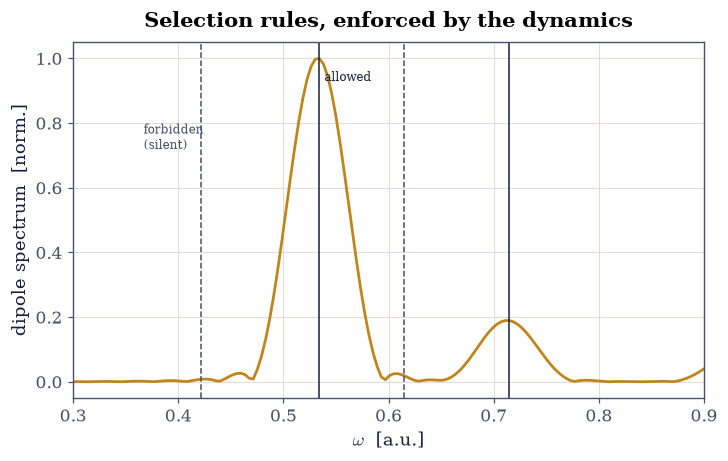

In [9]:
# (solution hidden on the public site)


### Validation 3 — two routes, one spectrum

Peaks on the eigenstate differences; forbidden windows far below the
weaker allowed line.

In [10]:
validate.check(
    bool(peak_dev < 2e-3),
    "propagation peaks = static excitation energies",
    f"worst deviation {peak_dev:.1e}",
)
validate.check(
    bool(
        allowed_second > 0.15
        and silent_triplet < allowed_second / 5.0
        and silent_even < allowed_second / 5.0
    ),
    "forbidden lines fivefold below the weaker allowed line",
    f"{100*silent_triplet:.2f}%, {100*silent_even:.2f}% vs allowed {100*allowed_second:.1f}%",
)

✓  propagation peaks = static excitation energies   [worst deviation 1.8e-04]
✓  forbidden lines fivefold below the weaker allowed line   [0.84%, 2.52% vs allowed 18.9%]


True

## Exercise 4 — TDHF: adiabatic exact exchange, priced

Now the approximate dynamics, starting with the best mean field on
offer. Both electrons share one orbital $\varphi$, which feels the mean
field of {eq}`eq-td-meanfield` with $c = \tfrac12$: the exchange
integral of a doubly occupied orbital cancels exactly half the Hartree
term, so each electron sees only the *other* one. Finding that orbital is
a fixed-point problem — the potential depends on the density the potential
produces — and the vocabulary is [§8.3](hartree-fock-atoms.ipynb)'s
mixing-damped SCF: diagonalize, mix the new orbital in at weight
$\alpha$, repeat. Two practical points decide whether the loop converges
at all. `numpy.linalg.eigh` fixes its eigenvectors only up to sign, so a
flipped iterate mixed against its predecessor would cancel rather than
converge; and the undamped map overshoots for this mean field, which is
what the damping is for. The closed-shell energies follow from the same
$c$: $E^{\mathrm{HF}} = 2\langle h\rangle + J$ against
$E^{\mathrm{H}} = 2\langle h\rangle + 2J$, with
$J = \iint |\varphi|^2 w |\varphi|^2$. Propagating this orbital differs
from Exercise 2 in exactly one respect, and it is the essential one: the
mean field is rebuilt from $|\varphi(t)|^2$ at every step, so the
Crank–Nicolson linear system changes each step and no factorization can be
reused — at $N = 121$ a dense solve is the right answer anyway. The
reference to beat is Exercise 1's exact $-2.2391$ and its first excitation
at $0.5339$.

**Part a)** Write `scf_orbital(hartree_factor, n_iter=200, mixing=0.3)`,
the damped SCF returning the converged orbital and the total energy for
either $c$. **Write this one yourself** — the implementation is the
lesson.

**Part b)** Run it at $c = \tfrac12$: $E^{\mathrm{HF}} = -2.2250$,
leaving $14.1$ mHa of correlation against the exact $-2.2391$ —
[§8.2](exact-laboratory.ipynb)'s percent-level verdict on HF, reproduced
in one dimension.

**Part c)** Write
`propagate_orbital(hartree_factor, kick=KICK, n_steps=N_STEPS, dt=DT)`,
the self-consistent Crank–Nicolson: kick the converged orbital with the
same pure phase, then step it with the mean field rebuilt from the
instantaneous density, recording the dipole $2\langle\varphi|x|\varphi\rangle$.
**Write this one yourself** — the implementation is the lesson.

**Part d)** Run it at $c = \tfrac12$ with Exercise 2's kick, step and
step count, and transform the record with the `dipole_spectrum` you wrote
in Exercise 3. The first spectral peak lands at $0.550$: blue-shifted from
the exact $0.534$ by $3.0\%$. That shift *is* the adiabatic exchange-only
TDDFT error for this system — correlation missing from both the ground
state and the response — and now it has a number.

In [11]:
# (solution hidden on the public site)


RHF energy -2.225017   exact -2.239071   correlation -14.1 mHa


TDHF first peak: 0.5498   exact 0.5339   shift +3.0%


### Validation 4 — correlation's price tag

The HF ground energy and its $14$ mHa deficit; the TDHF peak
blue-shifted by $3\%$ — small, systematic, and now measured.

In [12]:
validate.close(e_hf, -2.2250, "RHF ground energy", atol=1e-3)
validate.check(
    bool(-18.0 < corr_mha < -10.0),
    "correlation energy ~ -14 mHa (percent level, as in 8.2)",
    f"{corr_mha:.1f} mHa",
)
validate.check(
    bool(0.545 < hf_peak < 0.555 and 0.015 < hf_shift < 0.045),
    "TDHF blue-shifts the excitation by ~3%",
    f"peak {hf_peak:.4f}, shift {100*hf_shift:+.1f}%",
)

✓  RHF ground energy   [got -2.22502 vs expected -2.225 (rtol=1e-06, atol=0.001)]
✓  correlation energy ~ -14 mHa (percent level, as in 8.2)   [-14.1 mHa]
✓  TDHF blue-shifts the excitation by ~3%   [peak 0.5498, shift +3.0%]


True

## Exercise 5 — Verdict: the self-interaction catastrophe, and the scoreboard

The same dynamics with $c = 1$: each electron now repels the *full*
density, itself included.

**Part a)** Converge and kick the TD-Hartree system with the
`scf_orbital` and `propagate_orbital` you wrote in Exercise 4 — only the
argument changes — and transform the record with your Exercise 3
`dipole_spectrum`. Its spectrum is
not shifted — it is *wrecked*: the strongest line lands near $0.20$
— $62\%$ below the exact excitation — with further spurious structure
at $0.39$ and $0.63$, none of it corresponding to any exact
transition. The
self-interaction error that [§8.8](exact-conditions-band-gap.ipynb)
showed bending static curves here detunes the dynamics entirely: the
electron drags a phantom copy of itself through every oscillation.

**Part b)** Assemble the verdict figure — exact, TDHF, TD-Hartree
spectra against the exact excitation lines — and the scoreboard table:
method, ground energy, first-peak position, error. Two lessons, both
measured: *the mean field's quality decides the dynamics' quality*
(TDHF within $3\%$, Hartree off by tens of percent), and *removing
self-interaction is not optional* — the same two rules that govern
every functional on [§8.8](exact-conditions-band-gap.ipynb)'s static
battleground.

In [13]:
# (solution hidden on the public site)


TD-Hartree ground energy -1.528782 (self-interaction included)
TD-Hartree main peak: 0.2042   error -61.8%

--- Verdict: approximate dynamics vs the exact atom ---
      method   E_ground     peak    error
       exact    -2.2391   0.5339        —
        TDHF    -2.2250   0.5498    +3.0%
  TD-Hartree    -1.5288   0.2042   -61.8%


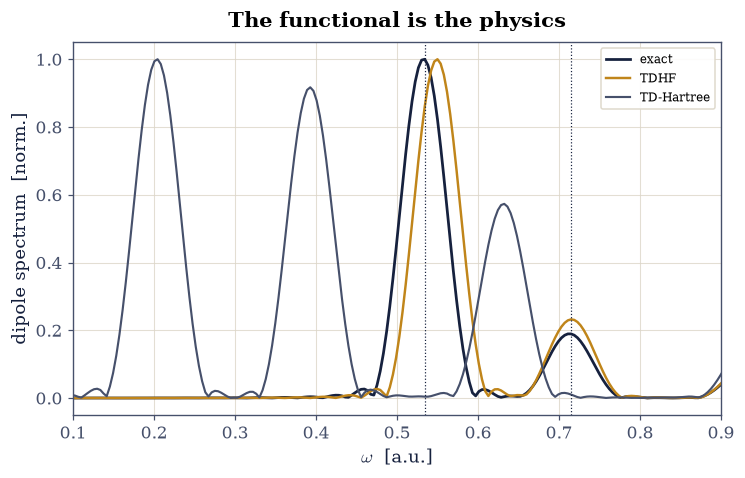

In [14]:
# (solution hidden on the public site)


### Validation 5 — wrecked, measurably

TD-Hartree far off where TDHF is close; the ordering of errors is the
lesson, and it is gated.

In [15]:
validate.check(
    bool(abs(hartree_err) > 0.15),
    "self-interaction detunes TD-Hartree by tens of percent",
    f"error {100*hartree_err:+.1f}%",
)
validate.check(
    bool(abs(hf_shift) < 0.05 < abs(hartree_err)),
    "mean-field quality decides dynamical quality (TDHF << Hartree error)",
    f"{100*abs(hf_shift):.1f}% vs {100*abs(hartree_err):.1f}%",
)
validate.check(
    bool(e_hartree > e_hf),
    "self-interaction raises the mean-field ground energy",
    f"{e_hartree:.4f} > {e_hf:.4f}",
)

✓  self-interaction detunes TD-Hartree by tens of percent   [error -61.8%]
✓  mean-field quality decides dynamical quality (TDHF << Hartree error)   [3.0% vs 61.8%]
✓  self-interaction raises the mean-field ground energy   [-1.5288 > -2.2250]


True

:::{admonition} With your assistant
:class: tip
Everything here was *linear* response — but the propagator does not
know that. Have your assistant rerun the exact propagation with a
*strong* kick ($\kappa = 0.5$, same $\Delta t$ and steps) and compute
the spectrum out to $\omega \approx 2$. Then run the check that is
yours alone: a third-harmonic line — spectral weight near
$3\times$ the fundamental that is absent in the $\kappa = 10^{-3}$
spectrum (compare the two spectra's weight in a window around
$3\omega_1$ with `numpy`, demanding a ratio $> 10$). Odd harmonics
from a centrosymmetric system: nonlinear optics, three lines of
`numpy` away from linear spectroscopy. The check is yours.
:::

## Notebook summary

The volume's exact laboratory learned to move. Its eight lowest states
were classified by exchange and parity — ground state $-2.2391$,
two dipole-active singlet-odd excitations at $0.5339$ and $0.7147$,
a triplet and an even singlet on the forbidden list — and the exact
real-time dynamics honored all of it: Crank–Nicolson with a
once-factorized sparse LU conserved the norm to $10^{-8}$ across
$4000$ steps, the kick response ratio under kick halving was
$2.0000$, linear to well within the $1\%$ tolerance, the spectral
peaks landed on the static excitation energies
at $2\times10^{-4}$, and the forbidden windows stayed fivefold below even the weaker
allowed line — spin and parity acting as selection rules *inside* the
propagator.
Against this certified answer, the two mean-field dynamics took their
grades: time-dependent Hartree–Fock (adiabatic exact exchange for this
system) reproduced the spectrum with a $+3.0\%$ blue shift on a
$-2.2250$ ground state ($14$ mHa of correlation missing — the same
deficit [§8.2](exact-laboratory.ipynb) measured); time-dependent
Hartree, self-interaction left in, landed $62\%$ low with spurious
structure — [§8.8](exact-conditions-band-gap.ipynb)'s static disease
as a dynamical catastrophe. The scoreboard is the point: TDDFT's
accuracy is exactly the accuracy of its functional, and the exact
testing ground is what makes that sentence quantitative.

## Outlook

- Production TDDFT propagates Kohn–Sham orbitals with adiabatic
  LDA/GGA functionals — better than Hartree (self-interaction partly
  cancelled), worse than exact exchange for two electrons; Ullrich
  {cite}`ullrich2012` maps the functional landscape, Casida's
  linear-response matrix reformulates the kick as an eigenproblem, and
  the known failures (double excitations, charge transfer, memory)
  all trace to the adiabatic approximation this notebook priced.
- The kick protocol scales: real codes compute molecular absorption
  exactly as Exercise 3 did, with the 2D grid swapped for Kohn–Sham
  orbitals in 3D.
- One movement remains: from excited electrons to *paired* ones. The
  volume's finale, [§8.17](bcs-superconductivity.ipynb), takes the
  attractive corner of the interaction map and finds the ground state
  nobody predicted: superconductivity.

```{bibliography}
:filter: docname in docnames
```

In [16]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>